In [2]:

import importlib
import scripts.clip_vid
importlib.reload(scripts.clip_vid)

from scripts.clip_vid import clip_video  # Import script to clip video
from scripts.stereo_calibration import stereo_calibrate_from_video


In [5]:
from scripts.clip_vid import clip_video

video_file = "/Users/oakley/Downloads/PMMX25_out_00_cal550-842.mp4"  # Video containing footage to be clipped

# Clip from start to finish and include frame rate (fps)
output_file = clip_video(video_file, start_minute=5, start_second=50, end_minute=8, end_second=42, fps=30, watch=False)


[INFO] Releasing video resources...
[INFO] Clipped video saved as: PMMX25_out_00_cal550-842_clipped_10500_15660.mkv


[INFO] Total frames in video: 5160


Processing Video:   0%|          | 0/5160 [00:00<?, ?frame/s]

[INFO] Processed 5160 frames. Detected checkerboard in 757 frames.


Retrieving full-res checkerboards:   0%|          | 0/757 [00:00<?, ?frame/s]

[INFO] Using 747 valid checkerboard frames for calibration.
[INFO] Calibrating individual cameras...
[INFO] Left Camera Matrix:
[[3.69593850e+04 0.00000000e+00 9.55987529e+02]
 [0.00000000e+00 1.56373709e+04 5.56175641e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
[INFO] Right Camera Matrix:
[[3.86161224e+04 0.00000000e+00 9.82073729e+02]
 [0.00000000e+00 1.69075222e+04 5.53917684e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
[INFO] Performing stereo calibration...
[INFO] Stereo calibration complete.
[INFO] Stereo calibration saved to stereo_calibration.npz
[INFO] Running stereo rectification visualization...
[INFO] Extracting first checkerboard frame for visualization...


Searching for first checkerboard frame:   0%|          | 0/5160 [00:00<?, ?frame/s]

[INFO] First detected checkerboard frame found. Performing rectification...
[DEBUG] P1:
[[ 1.62724465e+04  0.00000000e+00  1.34520387e+05  0.00000000e+00]
 [ 0.00000000e+00  1.62724465e+04 -6.56974121e+02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]]
[DEBUG] P2:
[[ 1.62724465e+04  0.00000000e+00  1.34520387e+05  7.21987177e+03]
 [ 0.00000000e+00  1.62724465e+04 -6.56974121e+02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]]
[DEBUG] Q:
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -1.34520387e+05]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  6.56974121e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.62724465e+04]
 [ 0.00000000e+00  0.00000000e+00 -2.25384148e+00  0.00000000e+00]]
[DEBUG] mapL1 min/max: 3048.182373046875, 3094.205810546875
[DEBUG] mapL2 min/max: 510.1940002441406, 567.6806640625
[DEBUG] mapR1 min/max: -2577.003662109375, -2254.013916015625
[DEBUG] mapR2 min/max: 514.2809448242

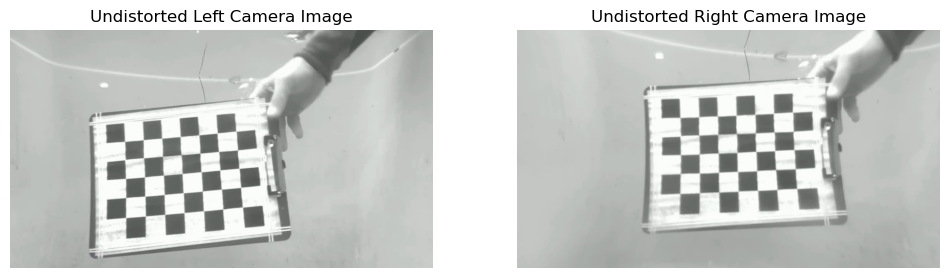

[INFO] Applying full rectification...


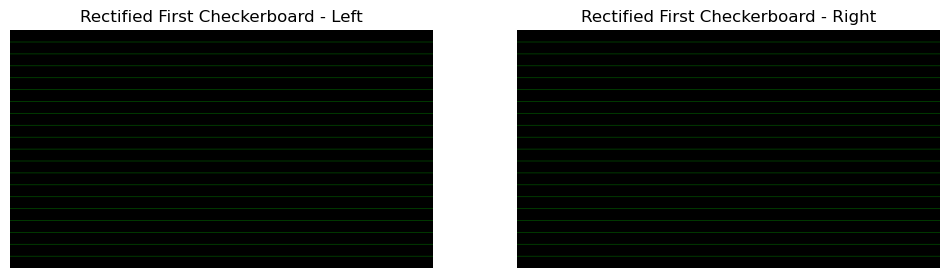

[INFO] Visualization complete.
Calibration file saved at: stereo_calibration.npz


In [6]:


video_file = "PMMX25_out_00_cal550-842_clipped_10500_15660.mkv"
# Calibration after flattening checkerboard
# video_file = "PMMX25_out_00_cal550-842_clipped_14100_15660.mkv"  # Use your clipped video
checkerboard_size = (5, 7)  # (rows, cols) of the checkerboard
square_size = 0.03  # Size of each square in meters


output_calib_file = stereo_calibrate_from_video(video_file, checkerboard_size, square_size, recalibrate=True)
if output_calib_file:
    print("Calibration file saved at:", output_calib_file)
else:
    print("Calibration failed: No checkerboard detections.")

